In [1]:
import pandas as pd

cus_df = pd.read_csv(r'C:\Machine\customer_segmentation_sample_full.csv', low_memory=False)

print("칼럼:", cus_df.columns)
print()
print("정보:")
cus_df.info()
print()
cus_df.describe()

칼럼: Index(['customer_id', 'segment_seed', 'monthly_visits', 'avg_purchase_amount',
       'monthly_total_spend', 'discount_usage_rate', 'online_purchase_ratio',
       'return_rate', 'membership_months', 'avg_session_minutes',
       'purchase_frequency_score', 'loyalty_points', 'complaint_count_6m'],
      dtype='object')

정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1200 non-null   object 
 1   segment_seed              1200 non-null   object 
 2   monthly_visits            1200 non-null   float64
 3   avg_purchase_amount       1185 non-null   float64
 4   monthly_total_spend       1200 non-null   float64
 5   discount_usage_rate       1185 non-null   float64
 6   online_purchase_ratio     1200 non-null   float64
 7   return_rate               1200 non-null   float64
 8   membersh

,monthly_visits,avg_purchase_amount,monthly_total_spend,discount_usage_rate,online_purchase_ratio,return_rate,membership_months,avg_session_minutes,purchase_frequency_score,loyalty_points,complaint_count_6m
count,1200.000000,1185.000000,1200.000000,1185.000000,1200.000000,1200.000000,1200.000000,1185.000000,1200.000000,1200.000000,1200.000000
mean,6.367315,128.592805,885.356172,0.364127,0.536170,0.056996,22.352909,11.798646,5.536125,884.522842,0.854167
std,4.132308,78.301804,842.368772,0.241565,0.191409,0.051285,12.877694,5.227252,2.906737,845.485509,1.074179
min,0.000000,13.908412,0.000000,0.000000,0.000000,0.000000,1.000000,1.521720,0.980000,0.000000,0.000000
25%,2.855786,63.356472,225.394784,0.168859,0.404462,0.021991,11.830107,7.531932,3.070000,218.000000,0.000000
50%,5.022131,96.301417,594.358504,0.307634,0.551507,0.041167,20.621198,10.907870,4.445000,596.500000,1.000000
75%,9.781873,187.781254,1348.534390,0.500648,0.676746,0.077184,31.733901,15.529392,8.045000,1302.750000,1.000000
max,19.705463,362.454453,5259.477618,1.000000,1.000000,0.283261,67.931076,30.550994,14.200000,4706.947472,8.000000


0
0.0
discount_usage_rate    0
avg_purchase_amount    0
avg_session_minutes    0
dtype: int64
결측량 확인: 0
결측치 비율: 0.0
Index(['customer_id', 'segment_seed', 'monthly_visits', 'avg_purchase_amount',
       'monthly_total_spend', 'discount_usage_rate', 'online_purchase_ratio',
       'return_rate', 'membership_months', 'avg_session_minutes',
       'purchase_frequency_score', 'loyalty_points', 'complaint_count_6m',
       'cluster'],
      dtype='object')
(1185, 6)
inertia: [5550.213932892776, 3834.0064288109406, 3079.9468607453227, 2829.3747548012325, 2705.8000388106893, 2550.4517996412096, 2388.9524494763928, 2268.1888536877796]
silhouette_score:[0.2187834029205718, 0.32123824836981235, 0.34100139516654926, 0.33902544651089495, 0.2677810261346327, 0.24881544904804953, 0.23680185488674094, 0.1858203430174342]
'Figure' object has no attribute 'set_title'
[0.3192752  0.27934021]


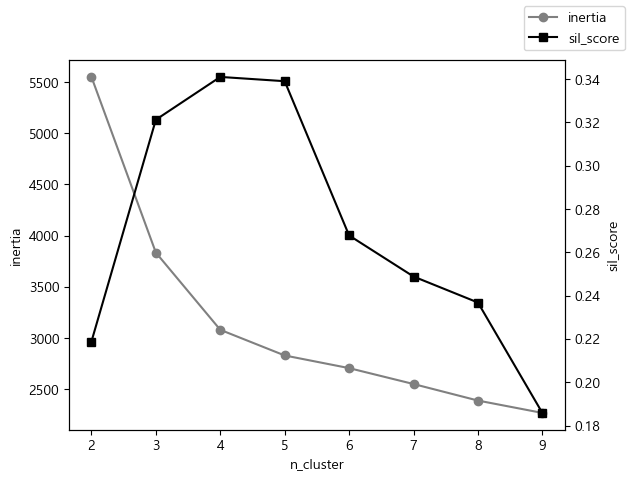

C:\Users\박중현\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


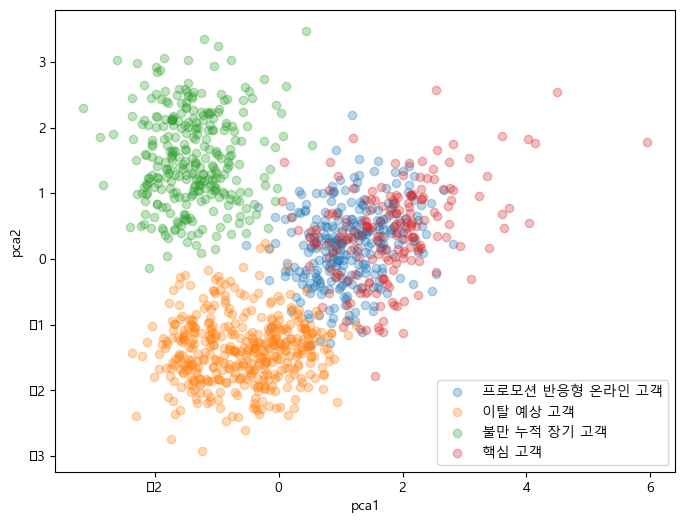

,monthly_total_spend,discount_usage_rate,online_purchase_ratio,return_rate,membership_months,complaint_count_6m
cluster,,,,,,
0,680.64,0.72,0.69,0.06,20.15,0.78
2,2179.87,0.21,0.57,0.03,36.82,0.64


In [18]:
#   4. 데이터 전처리
#       1)결측치 확인
        # 결측 비율이 몇 %인가
        # 결측이 특정 집단에 몰려 있는가
        # 결측 자체가 의미 있는 신호인가
        # 제거했을 때 표본 수가 얼마나 줄어드는가
        # 대치(imputation)와 비교했을 때 결과가 얼마나 달라지는가
na_array = cus_df['avg_purchase_amount'].isna() \
    | cus_df['discount_usage_rate'].isna() \
        | cus_df['avg_session_minutes'].isna()
print(len(cus_df[na_array]))
print(len(cus_df[na_array])/len(cus_df))
#       결측치는 평균구매량, 할인구매율, 평균활동시간에 고르게 퍼져있으며 총 45개의 샘플로 전체 샘플 대비 3%비율로 전반적으로 낮아 listwise deletion을 적용해도 무방한 것으로 보인다.
#       해당 칼럼을 제외한 칼럼에서 결측치가 없으므로 평균구매량과 평균활동시간의 결측은 외부 요인에 의한 단순 누락으로 보인다.
#       반면, 할인 구매율의 경우 할인 미사용(0)과 단순 누락을 구별할 합리적인 근거가 없으므로 해석상의 모호함이 존재한다.
#       본 분석은 해석상의 문제를 단순 제거함으로써 보수적으로 해결하였으며 단순 누락 결측치는 해당 열의 median으로 대체하였다. 
   
import numpy as np
print(cus_df[['discount_usage_rate', 'avg_purchase_amount', 'avg_session_minutes']].isna().sum())
print(f'결측량 확인: {na_array.sum()}')
print(f'결측치 비율: {na_array.mean()}')
cus_df = cus_df.dropna(subset=['discount_usage_rate']).copy() 
cus_df[['avg_purchase_amount', 'avg_session_minutes']] = cus_df[['avg_purchase_amount', 'avg_session_minutes']].fillna(cus_df[['avg_purchase_amount', 'avg_session_minutes']].median())


#       2)특성 선택
        # 분류 목적은 고객의 구매 성향을 파악하여 세그먼트를 세분화하는 것에 있으므로 구매 성향을 파악할 수 있는 특성 위주로 변수를 구성
print(cus_df.columns)
features = [
    'monthly_total_spend',
    'discount_usage_rate',
    'online_purchase_ratio',
    'return_rate',
    'membership_months',
    'complaint_count_6m'
]
cus_data = cus_df[features]

#       3)정규화
        #kmeans는 샘플 특성 내의 거리 기반 클러스터링 방법으로 데이터 단위가 큰 경우 정규화를 필요로 한다.
        #describe로 탐색한 결과, 데이터 특성 간 스케일 차이가 크므로 정규화를 실시
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
cus_scaled = ss.fit_transform(cus_data)
print(cus_scaled.shape)

#       5.군집수 탐색
#       엘보우와 실루엣 방식을 활용하여 적정 군집 수를 결정
#       엘보우, 실루엣, 군집 크기 균형, 해석 가능성을 종합 고려
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
try:    
    inertia = []
    sil_score = []
    for n in range(2, 10):
        km = KMeans(n_clusters=n, random_state=42)
        km.fit(cus_scaled)
        inertia.append(km.inertia_)
        
        score = silhouette_score(cus_scaled, km.labels_)
        sil_score.append(score)
       
        
    if inertia is not None and sil_score is not None:
        print(f'inertia: {inertia}')
        print(f'silhouette_score:{sil_score}')
        
        fig, ax1 = plt.subplots()
        ax1.plot(range(2, 10), inertia, marker='o', color='gray', label='inertia')
        ax1.set_xlabel('n_cluster')
        ax1.set_ylabel('inertia')
        ax2 = ax1.twinx()
        ax2.plot(range(2, 10), sil_score, marker='s', color='black', label='sil_score')
        ax2.set_ylabel('sil_score')
        fig.legend()
        fig.set_title('inerita/sil_score')
        fig.show()
                
except Exception as e:
    print(e)



# 엘보우 그래프 상 k=4인 지점부터 inertia 감소폭이 완만해졌고(군집효과 감소) 실루엣 점수 또한 해석 가능한 수준을 보여 최종 군집 수를 4로 선택항ㅆ다.
km = KMeans(n_clusters=4, random_state=42, n_init=20)
km.fit(cus_scaled)
km.labels_

#       6. 군집 결과 해석
cus_df['cluster'] = km.labels_
cluster_profile = cus_df.groupby(by=['cluster'])[features].mean().round(2)
cluster_by_mean = cus_df.groupby(by=['cluster'])[features].mean().round(2) - cus_df[features].mean().round(2)
# 0: 온라인 선호 할인 민감형 - 구매력 상위, 할인 민감(1위)
# 1: 무관심 고객층, 이탈 가능성 고객층 - 구매력, 할인, 멤버쉽 기간 모두 하위
# 2: 불만 누적 장기 고객층 - 멤버쉽을 장기간 유지하는 동시에 낮은 구매력과 높은 불만율, 반품율을 보임
# 3: 핵심 고객층 - 구매력과 멤버십 유지 기간 최상위. 구매력의 대부분을 차지하고 있음

#       7.시각화를 통한 검증
# 군집이 너무 겹치는지
# 한 군집만 너무 작은지
# 이상치가 따로 뭉쳤는지
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
cus_pca = pca.fit_transform(cus_scaled)
print(pca.explained_variance_ratio_)
pca_profile = pd.DataFrame(pca.components_, columns = features, index=['pca1', 'pca2']) 

names = {0: '프로모션 반응형 온라인 고객', 1: '이탈 예상 고객', 2: '불만 누적 장기 고객', 3: '핵심 고객'}
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(8, 6))
for l in np.unique(km.labels_):
        data = cus_pca[km.labels_ == l]
        plt.scatter(data[:, 0], data[:, 1], alpha=0.3, label=names[l])
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.legend()
plt.show()
#PCA 2차원 공간에서 군집 분포를 시각화한 결과, 무관심 고객층과 신중한 의사결정 고객층은 다른 군집과 비교적 명확히 분리되어 나타났다. 
# 반면 온라인 선호 할인 민감형과 핵심 고객층은 중심 영역에서 상당 부분 중첩되어, 두 군집 간 특성 차이는 존재하나 완전한 분리 상태는 아닌 것으로 보인다. 
# 따라서 본 군집화 결과는 일부 고객군에서는 분명한 세분화가 가능하지만, 일부 군집은 경계가 연속적일 가능성을 시사한다.

cluster_profile.loc[[0, 2]]
#두 군집 모두 온라인 구매 성향을 일부 공유하므로 PCA 공간상 일정 부분 중첩되지만, 소비 규모와 할인 민감도에서 뚜렷한 차이를 보인다.

In [ ]:
from sklearn.metrics import silhouette_score


0.34100139516654926


In [ ]:
# <최종 보고서>
# 본 분석은 고객의 구매 성향을 기반으로 세그먼트를 도출하는 것을 목적으로 하였다. 
# 결측치는 전체의 약 3% 수준으로 낮았으며, 평균구매액과 평균활동시간은 중간값 대치를, 할인구매율은 해석상 모호성을 고려해 해당 행 제거를 적용하였다.
# 이후 소비 규모, 할인 민감도, 온라인 구매 비율, 반품률, 가입기간, 불만 건수를 주요 특성으로 선정하고 표준화를 수행한 뒤 KMeans 군집화를 실시하였다. 
# 엘보우와 실루엣 결과를 종합해 군집 수는 4로 결정하였다. 
# 분석 결과 핵심 고객층, 온라인 할인 민감형, 저관여 고객층, 장기 유지 불만 고객층 등으로 구분 가능했으며, PCA 시각화에서는 일부 군집은 명확히 분리된 반면 일부 군집은 연속적으로 겹치는 양상을 보였기에 연속된 군집에 대한 의사결정시 클러스터 프로파일을 참고했다.

# 샘플데이터를 만든다

# 데이터 구조를 확인한다

# EDA로 분포/이상치를 본다

# 사용할 변수만 고른다

# 스케일링한다

# k를 여러 개 시험한다

# 최종 KMeans를 학습한다

# 군집별 평균표를 만든다

# 군집 이름을 붙인다

# 액션 아이디어까지 적는다